In [2]:
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import datasets
from itables import show, init_notebook_mode
import itables.options

init_notebook_mode(all_interactive=True)
itables.options.warn_on_undocumented_option=False

from kidneypy.eda import (
    profile_features,
    pairwise_correlation,
    pairwise_mutual_info,
)

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 50)
pd.set_option("display.width", 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

In [26]:
# X, y = datasets.load_iris(return_X_y=True, as_frame=True)
# X, y = datasets.load_diabetes(return_X_y=True, as_frame=True)
# X, y = datasets.load_digits(return_X_y=True, as_frame=True)
# X, y = datasets.load_linnerud(return_X_y=True, as_frame=True)
# X, y = datasets.load_wine(return_X_y=True, as_frame=True)
X, y = datasets.load_breast_cancer(return_X_y=True, as_frame=True)

X = pd.DataFrame(X)
y = pd.Series(y)
train = pd.concat([y, X], axis=1)
train.shape


(569, 31)

In [27]:
# infer_family(y)

target
1    357
0    212
Name: count, dtype: int64


<Axes: xlabel='target'>

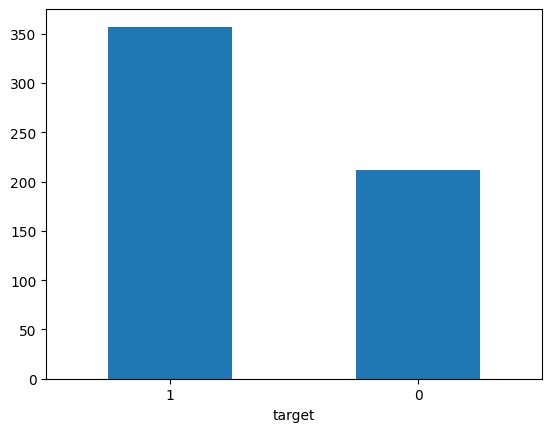

In [28]:
counts = y.value_counts()
print(counts.head())
# y.plot(kind='hist', bins=25)
counts.plot(kind='bar', rot=0)

In [ ]:
profile_df(train)

Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


In [25]:
cor = pairwise_correlation(X, method='pearson')
cor

Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


In [14]:
pairwise_correlation(X, method='cramers_v')

Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


In [19]:
mi = pairwise_mutual_info(X, y)
mi

Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


In [21]:
mi['col'][mi['mi'] > .3]

Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


In [22]:
train[mi['col'][mi['mi'] > .3]]

Loading ITables v2.7.0 from the init_notebook_mode cell... (need help?)


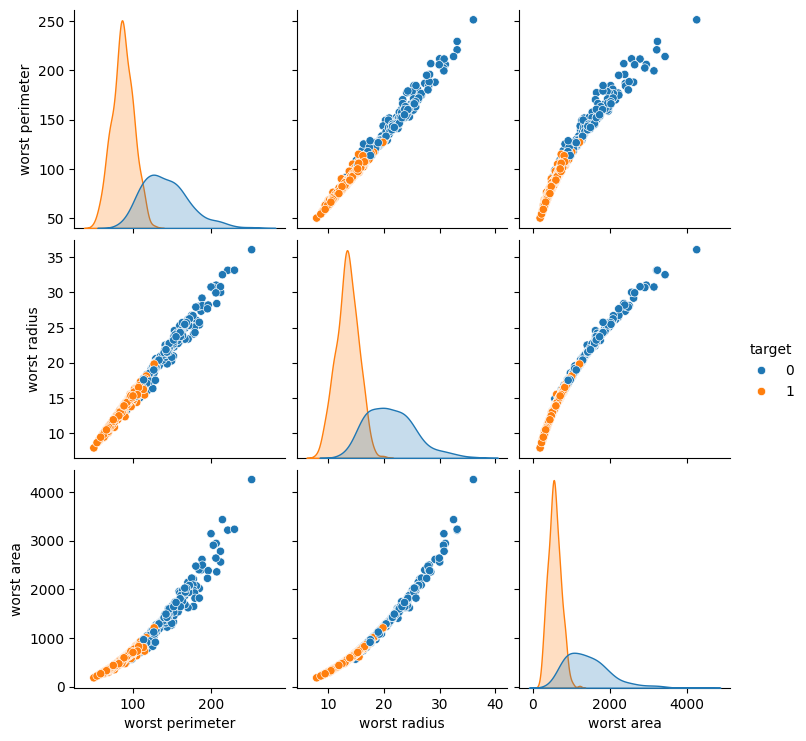

In [24]:
import seaborn as sns

cols = ['target'] + mi['col'][mi['mi'] > .3].to_list()

sns.pairplot(train[cols], hue='target')